In [1]:
import tensorflow as tf
from pathlib import Path
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../genetic_algorithm/src/")
from genepool import GenePool
from translation import translate

sys.path.append("../genetic_algorithm/utils/")
from substitute_tflite_layer import substitute_tflite_layer
from convert_to_tflite import convert_to_tflite

2023-11-21 14:39:27.609977: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Create params file with relevant parameters
params = {"path_gene_pool": "../gene_pool.txt", 
          "path_rule_set": "../rule_set.txt", 
          "population_size": 50,
          "max_nb_feature_layers": 30,
          "max_nb_classification_layers": 10, 
          "mutation_rate": 15, 
          
          "input_shape": (5000, 1), 
          "nb_classes": 10, 
          "sample_rate": 5000}

In [3]:
my_gene_pool = GenePool(params)

In [4]:
random_chromosomes = [my_gene_pool.get_random_chromosome() for _ in range(500)]

In [5]:
d = {'nb_params': [], 'length_tflite_model': []}

for chromosome in tqdm(random_chromosomes):
    try:
        model = translate(chromosome, params["input_shape"], params["nb_classes"], params["sample_rate"])
        
        #tflite_model = substitute_tflite_layer(model, params["input_shape"])
        
        #tflite_model = convert_to_tflite(tflite_model, np.random.uniform(size=(200, params["input_shape"][0], params["input_shape"][1])))
        
        trainableParams = np.sum([np.prod(v.get_shape()) for v in model.trainable_weights])
        nonTrainableParams = np.sum([np.prod(v.get_shape()) for v in model.non_trainable_weights])
        totalParams = trainableParams + nonTrainableParams
        
        d['nb_params'].append(totalParams)
        #d['length_tflite_model'].append(len(tflite_model))
 
        del model
        #del tflite_model
    except Exception as e:
        print(e)
        print(chromosome)
        break

  0%|          | 0/500 [00:00<?, ?it/s]

2023-11-21 14:39:29.948926: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-11-21 14:39:29.963561: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-11-21 14:39:29.963691: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:975] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-11-21 14:39:29.964044: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the approp

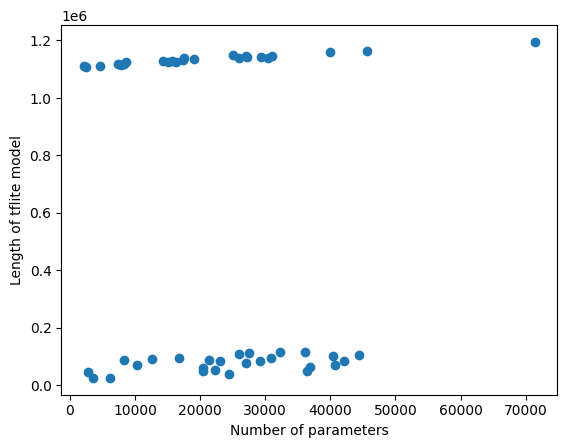

In [23]:
plt.plot(d['nb_params'], d['length_tflite_model'], 'o')
plt.xlabel('Number of parameters')
plt.ylabel('Length of tflite model')
plt.show()

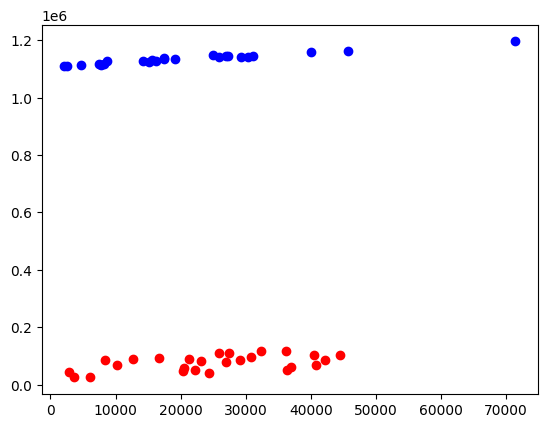

In [29]:
for nb_params, length_tflite_model, chromosome in zip(d["nb_params"], d["length_tflite_model"], random_chromosomes):
    for gene in chromosome:
        if gene['layer'] == 'STFT_2D':
            plt.scatter(nb_params, length_tflite_model, c='r')
            break
        elif gene['layer'] == 'MEL_2D':
            plt.scatter(nb_params, length_tflite_model, c='b')
            break